# 📧 Email Spam Detection with Naive Bayes

### Project Overview
This notebook builds an automated SMS/Email spam detector using Natural Language Processing (NLP) techniques and a **Multinomial Naive Bayes** classifier.

* **Dataset:** SMS Spam Collection Dataset (5,572 total messages)
* **Objective:** Accurately classify messages as either `Ham` (legitimate) or `Spam`.

In [17]:
#Importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Exploratory Data Analysis (EDA)
In this section, we load the dataset, check for missing values, and inspect the distribution between legitimate (`ham`) and `spam` messages to evaluate class imbalance.

In [3]:
df = pd.read_csv("/content/spam.csv")
df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.describe()

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [6]:
df.isnull().sum()

,0
Category,0
Message,0


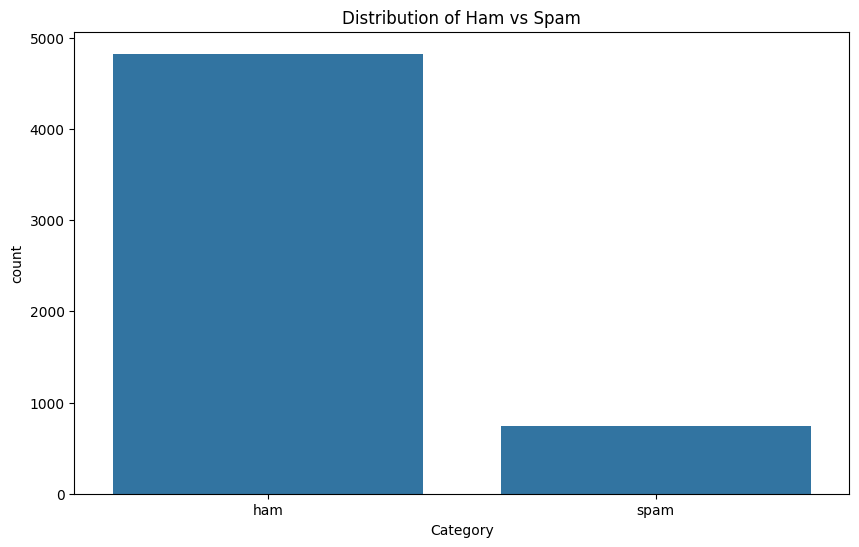

In [7]:
plt.figure(figsize = (10,6))

sns.countplot(x = df["Category"], data = df)
plt.title("Distribution of Ham vs Spam")
plt.show()

## 2. Model Training Pipeline
* Converted target labels into binary format (`ham` $\rightarrow$ 0, `spam` $\rightarrow$ 1).
* Split the dataset into **80% training** and **20% testing** sets using a fixed `random_state` for reproducibility.
* Built an end-to-end `scikit-learn Pipeline` combining `CountVectorizer` (text tokenization and bag-of-words vectorization) with `MultinomialNB`.

In [8]:
df["Category"] = df["Category"].map({"ham":0, "spam":1})
df.head()

,Category,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
from sklearn.model_selection import train_test_split

X = df["Message"]
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [10]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

clf = Pipeline([
    ("vectorizer", CountVectorizer()),
    ("nb", MultinomialNB())
])

In [11]:
clf.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

## 3. Evaluation & Results
We evaluate performance using **Precision**, **Recall**, **F1-Score**, and a **Confusion Matrix** to ensure that false positives (misclassifying legitimate emails as spam) are minimized.

In [13]:
accuracy = clf.score(X_test, y_test)

print(f"Overall Accuracy: {accuracy: .4f}\n")

Overall Accuracy:  0.9919



In [15]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

              precision    recall  f1-score   support

         Ham       0.99      1.00      1.00       966
        Spam       1.00      0.94      0.97       149

    accuracy                           0.99      1115
   macro avg       1.00      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



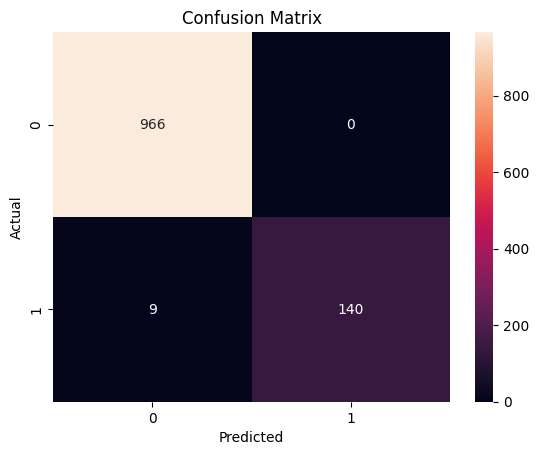

In [16]:
from sklearn import metrics
cm = metrics.confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 4. Testing & Inference
In this section, we pass new, unseen sample messages directly through our trained pipeline to test real-time spam detection capabilities.

In [20]:
sample_emails = [
    "Hey, are we still meeting for lunch today?",
    "CONGRATULATIONS! You've won a $1,000 gift card. Click here to claim now!"
]

# Pass raw text directly to the pipeline
predictions = clf.predict(sample_emails)

# Map numeric labels to text and print results
label_map = {0: "Ham", 1: "Spam"}

for email, pred in zip(sample_emails, predictions):
    print(f"Message: '{email}'")
    print(f"Prediction: {label_map[pred]}\n")

Message: 'Hey, are we still meeting for lunch today?'
Prediction: Ham

Message: 'CONGRATULATIONS! You've won a $1,000 gift card. Click here to claim now!'
Prediction: Spam



## 5. Model Serialization & Export
In this final section, we export the trained pipeline using `joblib` to save the model parameters to disk. This allows the classifier to be loaded and reused in external applications (e.g., Streamlit, Flask, or web microservices) without retraining.

In [21]:
import joblib

# 1. Save the trained pipeline model to disk
joblib.dump(clf, "spam_classifier_pipeline.joblib")
print("Model successfully saved as 'spam_classifier_pipeline.joblib'")

Model successfully saved as 'spam_classifier_pipeline.joblib'


In [22]:
# 2. Load the model back from disk (to simulate deployment)
loaded_model = joblib.load("spam_classifier_pipeline.joblib")

In [23]:
# 3. Test inference with the loaded model
sample = ["FREE entry into a $1,000 cash prize draw! Call now."]
prediction = loaded_model.predict(sample)

print(f"Loaded Model Prediction: {label_map[prediction[0]]}")

Loaded Model Prediction: Spam
